In [1]:
from random import randint
from typing import Literal

from langchain_core.messages import ToolMessage, SystemMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.messages import HumanMessage
from dotenv import load_dotenv
from langchain.tools import tool
load_dotenv(override=True)
from rich import print

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

# コード関数を使って外部API呼び出しの代わりに天気照会をシミュレート
@tool(parse_docstring=True)
def get_weather(city:str = "東京"):
    """
    指定された都市の当日の天気を照会する

    Args:
        city: 都市名
    """
    return f"{city}の天気は晴れです"

@tool(parse_docstring=True)
def get_news(domain:Literal["AI","食品安全"]):
    """
    特定分野の当日のホットニュースを照会する

    Args:
        domain: 特定の分野
    """
    if domain == "AI":
       return "Anthropic が Claude Opus-4.8 をリリースしましたが、API を通じて日本語で「あなたは誰ですか？」と送ると、ほとんどの場合返ってくるのは“Qwen”や“Deepseek”です。"
    elif domain == "食品安全":
        return "大手食肉メーカー子会社の豚肉製品から、抗生物質が基準値の37.5倍検出された"
    else:
        return "不明なニュース分野です"

# ツールをモデルにバインド
tools = [get_weather,get_news]
model_with_tool = model.bind_tools(tools=tools)

res = model_with_tool.invoke(input="今日の東京の天気とAIニュースを調べてください")
print(res)


AIMessage(
    content='',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 75,
            'prompt_tokens': 373,
            'total_tokens': 448,
            'completion_tokens_details': None,
            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
            'prompt_cache_hit_tokens': 0,
            'prompt_cache_miss_tokens': 373
        },
        'model_provider': 'deepseek',
        'model_name': 'deepseek-v4-flash',
        'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e',
        'id': '9bd3c876-bcb5-42d8-8a74-baf439418bf8',
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='lc_run--019fff0f-7e3e-7de0-8019-cb7e4ca1fcfe-0',
    tool_calls=[
        {
            'name': 'get_weather',
            'args': {'city': '東京'},
            'id': 'call_00_6NmDsCwCvVp8w7WN140m2364',
            'type': 'tool_call'
        },
        {
            'name': 'get_news',
            'args': {'domain': 'AI'},
            'id': 'call_01_Y21rjC59hqcKd1eu0Ipf8146',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 373,
        'output_tokens': 75,
        'total_tokens': 448,
        'input_token_details': {'cache_read': 0},
        'output_token_details': {}
    }
)

user_input: 今日の東京の天気とAIニュースのホットトピックを調べてください

final_output: 今日の東京の天気とAIニュースのホットトピックの情報が取得できました。以下にまとめます。

---

### 🌤️ 今日の東京の天気
**晴れ**

---

### 🤖 AIニュースのホットトピック
**Anthropic が Claude Opus-4.8 
をリリースしましたが、APIを通じて日本語で「あなたは誰ですか？」と送ると、ほとんどの場合返ってくるのは"Qwen"や"Deeps
eek"です。**

---

**まとめ：** 今日の東京は晴れで、AI分野ではAnthropicのClaude 
Opus-4.8リリースに関するニュースが注目されています。天気が良いので、外出日和ですね！

================================ System Message ================================

ツール呼び出しが失敗した場合は、成功するまで必ず再呼び出ししてください
================================ Human Message =================================

今日の東京の天気とAIニュースのホットトピックを調べてください
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_00_f3nhOlhYAaOigdd52YAR1778)
 Call ID: call_00_f3nhOlhYAaOigdd52YAR1778
  Args:
    city: 東京
  get_news (call_01_S6TiMUgji6TMIvPiB5MF5095)
 Call ID: call_01_S6TiMUgji6TMIvPiB5MF5095
  Args:
    domain: AI
================================= Tool Message =================================

ネットワークが不安定です。呼び出しに失敗しました。再試行してください
================================= Tool Message =================================
Name: get_news

Anthropic が Claude Opus-4.8 をリリースしましたが、API を通じて日本語で「あなたは誰ですか？」と送ると、ほとんどの場合返ってくるのは“Qwen”や“Deepseek”です。
================================== Ai Message ==================================

天気の取得に失敗したので、再試行します。
Tool Calls:
  get_weather (call

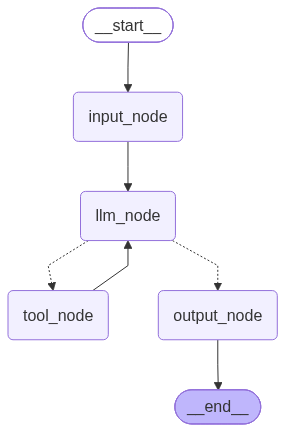

In [4]:
#1. 状態を宣言
class OverAllState(MessagesState):
    user_input:str
    final_output:str

#2. ノードを宣言
#2.1 入力ノード => ユーザーが入力したクエリ情報をメッセージに記録し、後続の大規模言語モデル呼び出しに備える
def input_node(state:OverAllState) -> OverAllState:
    return {
        "messages": [HumanMessage(state["user_input"])]
    }

#2.2 大規模言語モデルノード
def llm_node(state:OverAllState) -> OverAllState:
    ai_msg = model_with_tool.invoke(state["messages"])
    return {
        "messages":ai_msg
    }

#2.3 ツール呼び出しが必要かどうかを判定
def tool_node(state:OverAllState) -> OverAllState:
    # 大規模言語モデルの返答内容から tool 呼び出しが必要かどうかを判定
    messages = state["messages"]
    ai_msg = messages[-1]
    tool_calls = ai_msg.tool_calls

    # 6は関数呼び出しが60%の確率で失敗することを表す
    fail_prob = 6

    for tool_call in tool_calls:
        if tool_call["name"]== "get_weather":
            # [0-9] の数字を生成して大小を判定
            if randint(0,9) < fail_prob:
                messages.append(ToolMessage(
                    content="ネットワークが不安定です。呼び出しに失敗しました。再試行してください",
                    tool_call_id = tool_call["id"]
                ))
            else:
                messages.append(get_weather.invoke(tool_call))
        elif tool_call["name"] == "get_news":
            if randint(0,9) < fail_prob:
                messages.append(ToolMessage(
                    content="ネットワークが不安定です。呼び出しに失敗しました。再試行してください",
                    tool_call_id = tool_call["id"]
                ))
            else:
                messages.append(get_news.invoke(tool_call))
        else:
            messages.append(ToolMessage(
                content="ツール名が誤っています。呼び出しに失敗しました。再試行してください",
                 tool_call_id = tool_call["id"]
                 ))
    return {
        "messages":messages
    }


#2.4 出力ノードを返す
def output_node(state:OverAllState) -> OverAllState:
    return {
        "final_output":state["messages"][-1].content
    }

#2.5 ツールノードの呼び出しが必要か、それとも直接 output ノードへ進むかを判定
def router(state:OverAllState) -> Literal["tool_node","output_node"]:
    messages = state["messages"]
    last_msg = messages[-1]
    if last_msg.tool_calls:
        return  "tool_node"
    return "output_node"

#3. グラフを構築
builder = StateGraph(state_schema=OverAllState)
builder.add_node("input_node",input_node)
builder.add_node("llm_node",llm_node)
builder.add_node("tool_node",tool_node)
builder.add_node("output_node",output_node)

builder.add_edge(START,"input_node")
builder.add_edge("input_node","llm_node")
builder.add_conditional_edges("llm_node",router)
builder.add_edge("tool_node","llm_node")
builder.add_edge("output_node",END)

graph = builder.compile()

ai_res = graph.invoke({
    "user_input":"今日の東京の天気とAIニュースのホットトピックを調べてください",
    "messages":[SystemMessage("ツール呼び出しが失敗した場合は、成功するまで必ず再呼び出ししてください")]
})

print("user_input:",ai_res["user_input"])
print("final_output:",ai_res["final_output"])
for msg in ai_res["messages"]:
    msg.pretty_print()

from IPython.display import  display
display(graph)

